# Introduction

**Goal:** Generate plausible peptides with high antimicrobial activity.

To find such peptides, we will need two things:
- 🗺️ **A Map**, which will describe a landscape of plausible peptides.
- 🧭 **A Compass**, which will guide us toward peptides with high antimicrobial activity. 


The **Map** will be provided by the latent space of the variational autoencoder [HydrAMP (Szymczak et al., 2023)](https://doi.org/10.1038/s41467-023-36994-z). 

The **Compass** will be an antimicrobial activity predictor, namely APEX [Wan et al., 2024](https://doi.org/10.1038/s41551-024-01201-x)

Plan:
1. Get familiar with the "map" - HydrAMP autoencoder
2. Get familiar with the "compass" - APEX model
3. Global exploration and Optimization
4. Local Exploration and Optimization



# Installation

TODO: create installation guideline
- needed packages
- CPU or GPU environment in google colab

In [110]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import torch
from sklearn.decomposition import PCA
import numpy as np

import logomaker
from pep_compass.autoencoder.factory import AutoencoderFactory
from pep_compass.autoencoder.strategies.hydramp.adapter import HydrampAutoencoder
import warnings




# 🗺️ **The Map** - Autoencoder


TODO: Add some image with autoencoder archiotecture. From some presentations

In [ ]:
autoencoder: HydrampAutoencoder = AutoencoderFactory.build(
    "hydramp",
    model="article_25",
    device="cpu",
    jacobian_eps=0.001,
    field_eps=0.001,
    jacobian_mode="approx"
)

/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Once we have the autoencoder in hand, let's embed peptides and visualize the latent space with PCA.

Let's also sample a few points from the latent space. 

In [25]:
# TODO: write correct path to the peptides.csv file. Remove absolute path.
PEPTIDE_DATASET_PATH = "/home/adambiel/pep-compass/data/peptides_data/peptides_raw/peptides.csv"
peptide_dataset = pd.read_csv(PEPTIDE_DATASET_PATH)
background_peptides = peptide_dataset["sequence"].sample(10000, random_state=32).values

print("First 10 background peptides:")
background_peptides[:10]

First 10 background peptides:


array(['FLVTLGLNIVSGIVLKRYREVYQ', 'MLWRLVQQWSV', 'MSWKKALRIPGGLRAATVTLML',
       'AVHDRQAAELAWGRAIAFLKKRLG', 'IFMAVFKKRVVYTKYRHDRHAIK',
       'TMGNPKPSVSWVKGETVVKETARIA', 'QLLKKYKNKIISVALLAIYFFDYR',
       'MVDVAHLERMGRELKCPI', 'MLALNNNLLEGPIPLSIYQLVR',
       'MNMFTVLTSCSVWLNTQNCGT'], dtype=object)

In [26]:
latent_background = autoencoder.encode_peptides(background_peptides)
latent_background.shape

torch.Size([10000, 64])

In [105]:
PCA_COMPONENTS = (0, 1)  # PCA components to plot

pca = PCA(n_components=64)
latent_background_projected = pca.fit_transform(latent_background.detach().cpu().numpy())

# Mean and variance in PCA space
mean = np.zeros(pca.n_components_)
variance = pca.explained_variance_

# Sample PCA coordinates
n_samples = 5

sampled_latent_points = np.random.normal(
    loc=mean,
    scale=np.sqrt(variance),
    size=(n_samples, pca.n_components_),
)

fig = go.Figure()

background_lengths = [len(peptide) for peptide in background_peptides]

fig.add_trace(go.Scattergl(
    x=latent_background_projected[:, PCA_COMPONENTS[0]],
    y=latent_background_projected[:, PCA_COMPONENTS[1]],
    mode="markers",
    name="Background peptides",
    marker={
        "size": 6,
        "opacity": 0.5,
        "color": background_lengths,
        "colorscale": "Viridis",
        # "colorbar": {"title": "Sequence length"},
        "colorbar": {
            "title": "Sequence length",
            "len": 0.5,
            "y": 0.5,
            "yanchor": "middle",
            "x": 1.02,
        },
    },
    customdata=[
        (sequence, length)
        for sequence, length in zip(background_peptides, background_lengths)
    ],
    hovertemplate=(
        "Sequence: %{customdata[0]}<br>"
        "Length: %{customdata[1]}<br>"
        f"PC{PCA_COMPONENTS[0]}: " + "%{x:.4f}<br>"
        f"PC{PCA_COMPONENTS[1]}: " + "%{y:.4f}<extra></extra>"
    ),
))

fig.add_trace(go.Scattergl(
    x=sampled_latent_points[:, PCA_COMPONENTS[0]],
    y=sampled_latent_points[:, PCA_COMPONENTS[1]],
    mode="markers",
    name="Sampled latent points",
    marker={
        "size": 10,
        "opacity": 1,
        "color": "red",
    },
    hovertemplate=(
        "Sampled latent point<br>"
        f"PC{PCA_COMPONENTS[0]}: " + "%{x:.4f}<br>"
        f"PC{PCA_COMPONENTS[1]}: " + "%{y:.4f}<extra></extra>"
    ),
))

fig.update_layout(
    title="Interactive PCA projection of latent positions",
    xaxis_title=f"PC{PCA_COMPONENTS[0]} ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC{PCA_COMPONENTS[1]} ({pca.explained_variance_ratio_[1]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()


Let's decode sampled latent points (red dots) and see how the point in the ambient space look like.

In [123]:
# Transform back to original space
latent_samples = pca.inverse_transform(sampled_latent_points)
latent_samples = torch.tensor(latent_samples, dtype=torch.float32)

with torch.inference_mode():
    ambient_decoded_samples = autoencoder.decoder_forward(latent_samples, softmax=True, flatten=False)

In [124]:
ambient_decoded_samples.shape

torch.Size([5, 25, 21])

- One ambient point is a tensor of size 25 x 21. 
- 25 correspond to maximum sequence length.
- 21 correspond to amino-acid alphabet with additional `<pad>` character

In [128]:
alphabet = ["<pad>"] + list("ACDEFGHIKLMNPQRSTVWY")
print(f"{alphabet=}")

alphabet=['<pad>', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']


Let's visualize one ambient point as a table and let's inspect the content of entries.

One ambient point corresponds to a position-wise factorized probability distribution over the amino acid alphabet.
It means that on every position there is a categorical probability distribution.

In [138]:
SAMPLE_INDEX = 3  # Change this index to 0, 1, 2, 3, or 4 to visualize different sampled peptides

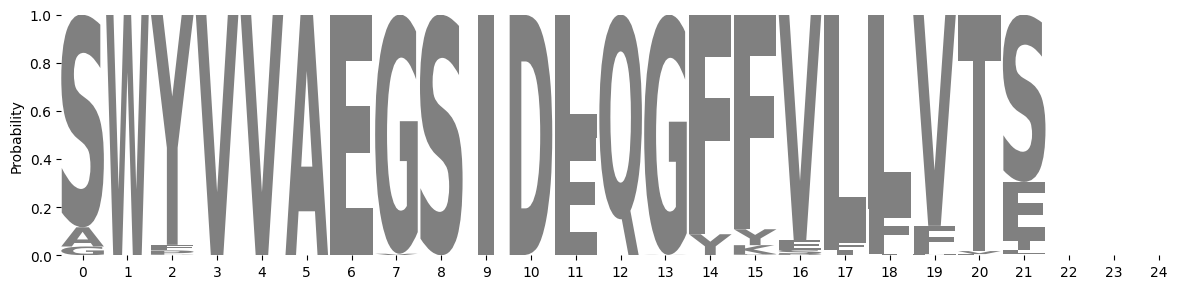

In [139]:
decoded_sample_numpy = (
    ambient_decoded_samples[SAMPLE_INDEX]
    .T.detach()
    .cpu()
    .numpy()
)

color_limit = 1

fig = go.Figure(
    go.Heatmap(
        z=decoded_sample_numpy,
        y=alphabet,
        colorscale="Greens",
        zmin=0,
        zmax=1,
        colorbar={"title": "Probability"},
        hovertemplate=(
            "Position: %{x}<br>"
            "Amino acid: %{y}<br>"
            "Probability: %{z:.2}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=f"Soft peptide",
    xaxis_title="Peptide residue",
    yaxis_title="Alphabet",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

amino_acids = list(" ACDEFGHIKLMNPQRSTVWY")


def plot_logo(matrix, ax, title="", verbose=False):

    if not verbose:
        warnings.filterwarnings("ignore")
    df = pd.DataFrame(matrix.T, columns=amino_acids)
    df.index.name = "pos"

    logo = logomaker.Logo(df, ax=ax)
    logo.style_spines(visible=False)
    logo.style_xticks(anchor=0, spacing=1)

    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Probability")

plt.figure(figsize=(12, 3))
ax = plt.gca()
plot_logo(decoded_sample_numpy, ax=ax)
plt.tight_layout()
plt.show()

# Peptide Representation


# Autoencoder


In [32]:
decoded_background = autoencoder.decoder_forward(latent_background)

In [33]:
decoded_background.shape

torch.Size([10000, 525])

In [34]:
pca_ambient = PCA(n_components=525)
ambient_projected = pca_ambient.fit_transform(decoded_background.detach().cpu().numpy())

In [35]:
sampled_ambient_projected = pca_ambient.transform(decoded_sampled.detach().cpu().numpy())

In [36]:
ambient_projected.shape

(10000, 525)

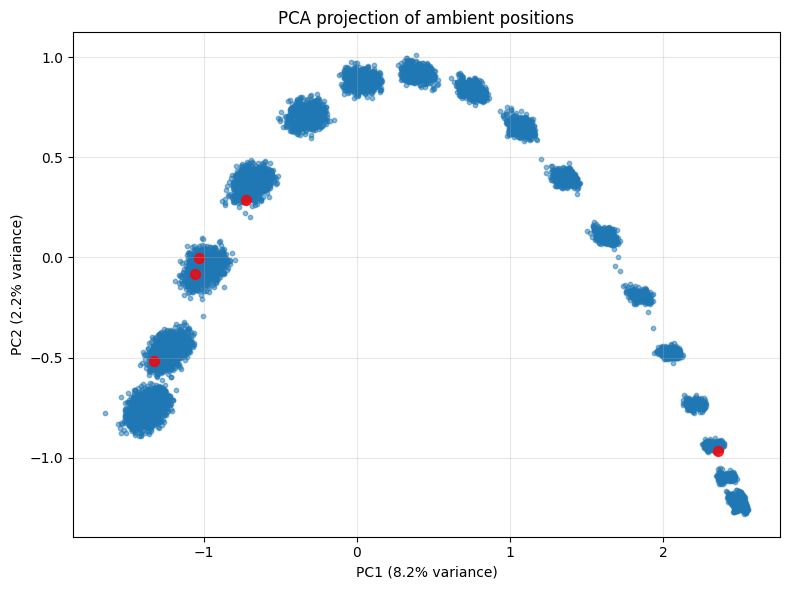

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(
    ambient_projected[:, 0],
    ambient_projected[:, 1],
    s=10,
    alpha=0.5,
)
plt.scatter(
    sampled_ambient_projected[:, 0],
    sampled_ambient_projected[:, 1],
    s=50,
    alpha=0.8,
    color="red",
)

plt.xlabel(f"PC1 ({pca_ambient.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_ambient.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA projection of ambient positions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
import plotly.graph_objects as go

fig = go.Figure()

DIM_0 = 0
DIM_1 = 1

background_lengths = [len(peptide) for peptide in background_peptides]

fig.add_trace(go.Scattergl(
    x=ambient_projected[:, DIM_0],
    y=ambient_projected[:, DIM_1],
    mode="markers",
    name="Background peptides",
    marker=dict(
        size=6,
        opacity=0.5,
        color=background_lengths,
        colorscale="Viridis",
        colorbar=dict(title="Sequence length"),
    ),
    customdata=[
        (sequence, length)
        for sequence, length in zip(background_peptides, background_lengths)
    ],
    hovertemplate=(
        "Sequence: %{customdata[0]}<br>"
        "Length: %{customdata[1]}<br>"
        "PC1: %{x:.4f}<br>"
        "PC2: %{y:.4f}<extra></extra>"
    ),
))

fig.add_trace(go.Scattergl(
    x=sampled_ambient_projected[:, DIM_0],
    y=sampled_ambient_projected[:, DIM_1],
    mode="markers",
    name="Sampled peptides",
    marker=dict(size=10, color="red", opacity=0.8),
    customdata=sampled_peptides,
    hovertemplate=(
        "Sequence: %{customdata}<br>"
        "PC1: %{x:.4f}<br>"
        "PC2: %{y:.4f}<extra></extra>"
    ),
))

fig.update_layout(
    title="Interactive PCA projection of ambient positions",
    xaxis_title=f"PC1 ({pca_ambient.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca_ambient.explained_variance_ratio_[1]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
    showlegend=True,
)

fig.show()

In [39]:
import umap

umap_ambient = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=32,
)

ambient_umap = umap_ambient.fit_transform(
    decoded_background.detach().cpu().numpy()
)
sampled_ambient_umap = umap_ambient.transform(
    decoded_sampled.detach().cpu().numpy()
)

fig = go.Figure()

background_lengths = [len(peptide) for peptide in background_peptides]

fig.add_trace(go.Scattergl(
    x=ambient_umap[:, 0],
    y=ambient_umap[:, 1],
    mode="markers",
    name="Background peptides",
    marker=dict(
        size=6,
        opacity=0.5,
        color=background_lengths,
        colorscale="Viridis",
        colorbar=dict(title="Sequence length"),
    ),
    customdata=[
        (peptide, length)
        for peptide, length in zip(background_peptides, background_lengths)
    ],
    hovertemplate=(
        "Sequence: %{customdata[0]}<br>"
        "Length: %{customdata[1]}<br>"
        "UMAP1: %{x:.4f}<br>"
        "UMAP2: %{y:.4f}<extra></extra>"
    ),
))

fig.add_trace(go.Scattergl(
    x=sampled_ambient_umap[:, 0],
    y=sampled_ambient_umap[:, 1],
    mode="markers",
    name="Sampled peptides",
    marker=dict(size=10, color="red", opacity=0.8),
    customdata=sampled_peptides,
    hovertemplate=(
        "Sequence: %{customdata}<br>"
        "UMAP1: %{x:.4f}<br>"
        "UMAP2: %{y:.4f}<extra></extra>"
    ),
))

fig.update_layout(
    title="Interactive UMAP projection of ambient positions",
    xaxis_title="UMAP1",
    yaxis_title="UMAP2",
    template="plotly_white",
    width=900,
    height=650,
    showlegend=True,
)

fig.show()

/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# Oracle

In [40]:
import numpy as np

from pep_compass.optimization.components.oracles.strategies.apex.oracle import (
    APEXBlackBox,
)

peptide = "FLYKWWIRIGRLKL"

oracle = APEXBlackBox(
    model="default",
    device="cuda:3",
    mic_aggregate="mean",  # or "max"
    mic_bacteria="all",    # or e.g. [1, 2, 3]
    batch_size=32,
)

score = oracle.score([peptide])[0]

print(f"Peptide: {peptide}")
print(f"APEX score (mean log2 MIC): {score:.4f}")
assert np.isfinite(score)

Peptide: FLYKWWIRIGRLKL
APEX score (mean log2 MIC): 4.7120


In [41]:
background_peptides.tolist()

['FLVTLGLNIVSGIVLKRYREVYQ',
 'MLWRLVQQWSV',
 'MSWKKALRIPGGLRAATVTLML',
 'AVHDRQAAELAWGRAIAFLKKRLG',
 'IFMAVFKKRVVYTKYRHDRHAIK',
 'TMGNPKPSVSWVKGETVVKETARIA',
 'QLLKKYKNKIISVALLAIYFFDYR',
 'MVDVAHLERMGRELKCPI',
 'MLALNNNLLEGPIPLSIYQLVR',
 'MNMFTVLTSCSVWLNTQNCGT',
 'KRSVKALPALPQRPTSFLPVTARW',
 'VSVAVSVVETVFVAVVVSVLVV',
 'PLYRVVKAMASMQAIVNKGQRRR',
 'RARRICII',
 'MSSSTHLSFLWLFEPSVRK',
 'ACAKGLLLAATGWLMRMLLLLPGNL',
 'MLSLESQGSSAL',
 'MDRALVDRWPALQLSKIR',
 'MSNSQLMFWNCYSGTLQDWLRSR',
 'AALSAAAVRFVRVASLLRALLMVMV',
 'AEVSSTNG',
 'ALKAYAALTTSAARGAVRIVPE',
 'VTVGYKVVSAVEWLMDRLLHLK',
 'MQVRVERGQLIIQVVTED',
 'MKNQKKRKTEKTLQHSFHLGDL',
 'MMQDMVRKLVKDKVAPRAAEIDETD',
 'MSSGIRTAIVHRTEVHWDDGHVERL',
 'MCCSFVRVKGTAHFTWCSIIAN',
 'MVATVWKT',
 'GIMSSLMKKLKAHIAK',
 'KCYAVWS',
 'MEYKPHDASRRDNSSYRNTWLRG',
 'PLEVPTAPSSLFIGLK',
 'MHRTGRGMPPAGWPHRPHWQHGG',
 'RVLQRLIPAVKPTGVVSSDDGAFWN',
 'MKRTYQPSKRTRKRQHGFRA',
 'MVFNVTLYGETKR',
 'MESSRHPGG',
 'LALTIRYSRYALSALSSVGFTLTSN',
 'MYISCELAIAEK',
 'NQMLYQDELEQEEKYNGRSQEN',


In [42]:
scores = oracle.score(background_peptides.tolist())

In [43]:
import plotly.graph_objects as go

fig = go.Figure()

DIM_0 = 0
DIM_1 = 1

background_lengths = [len(peptide) for peptide in background_peptides]

fig.add_trace(go.Scattergl(
    x=ambient_projected[:, DIM_0],
    y=ambient_projected[:, DIM_1],
    mode="markers",
    name="Background peptides",
    marker=dict(
        size=6,
        opacity=0.5,
        color=scores,
        colorscale="Viridis",
        colorbar=dict(title="Sequence length"),
    ),
    customdata=[
        (sequence, length)
        for sequence, length in zip(background_peptides, scores)
    ],
    hovertemplate=(
        "Sequence: %{customdata[0]}<br>"
        "Length: %{customdata[1]}<br>"
        "PC1: %{x:.4f}<br>"
        "PC2: %{y:.4f}<extra></extra>"
    ),
))

fig.add_trace(go.Scattergl(
    x=sampled_ambient_projected[:, DIM_0],
    y=sampled_ambient_projected[:, DIM_1],
    mode="markers",
    name="Sampled peptides",
    marker=dict(size=10, color="red", opacity=0.8),
    customdata=sampled_peptides,
    hovertemplate=(
        "Sequence: %{customdata}<br>"
        "PC1: %{x:.4f}<br>"
        "PC2: %{y:.4f}<extra></extra>"
    ),
))

fig.update_layout(
    title="Interactive PCA projection of ambient positions",
    xaxis_title=f"PC1 ({pca_ambient.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca_ambient.explained_variance_ratio_[1]:.1%} variance)",
    template="plotly_white",
    width=900,
    height=650,
    showlegend=True,
)

fig.show()

(array([2.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 7.000e+00, 8.000e+00,
        1.000e+00, 2.000e+00, 3.000e+00, 4.000e+00, 1.000e+01, 1.300e+01,
        1.500e+01, 1.400e+01, 1.800e+01, 1.700e+01, 1.700e+01, 1.600e+01,
        2.500e+01, 2.400e+01, 3.100e+01, 3.100e+01, 3.700e+01, 2.800e+01,
        5.200e+01, 5.600e+01, 6.400e+01, 8.100e+01, 9.200e+01, 8.200e+01,
        1.260e+02, 1.790e+02, 2.170e+02, 2.930e+02, 4.290e+02, 6.860e+02,
        1.438e+03, 5.864e+03]),
 array([4.25418711, 4.34917307, 4.44415903, 4.53914499, 4.63413095,
        4.72911692, 4.82410288, 4.91908884, 5.0140748 , 5.10906076,
        5.20404673, 5.29903269, 5.39401865, 5.48900461, 5.58399057,
        5.67897654, 5.7739625 , 5.86894846, 5.96393442, 6.05892038,
        6.15390635, 6.24889231, 6.34387827, 6.43886423, 6.53385019,
        6.62883568, 6.72382164, 6.81

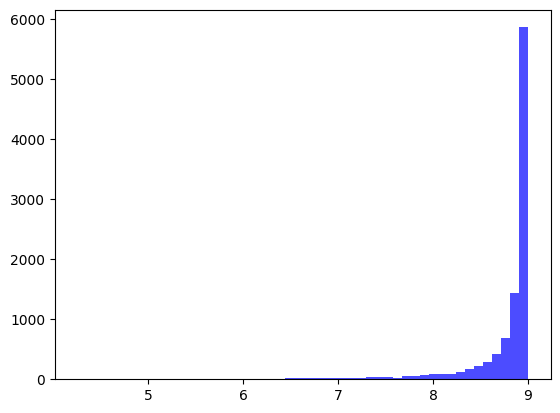

In [44]:
plt.hist(scores, bins=50, color="blue", alpha=0.7)

In [45]:
import umap

umap_ambient = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=32,
)

ambient_umap = umap_ambient.fit_transform(
    decoded_background.detach().cpu().numpy()
)
sampled_ambient_umap = umap_ambient.transform(
    decoded_sampled.detach().cpu().numpy()
)

fig = go.Figure()

background_lengths = [len(peptide) for peptide in background_peptides]

fig.add_trace(go.Scattergl(
    x=ambient_umap[:, 0],
    y=ambient_umap[:, 1],
    mode="markers",
    name="Background peptides",
    marker=dict(
        size=6,
        opacity=0.5,
        color=scores,
        colorscale="Viridis",
        colorbar=dict(title="Sequence length"),
    ),
    customdata=[
        (peptide, length)
        for peptide, length in zip(background_peptides, scores)
    ],
    hovertemplate=(
        "Sequence: %{customdata[0]}<br>"
        "Length: %{customdata[1]}<br>"
        "UMAP1: %{x:.4f}<br>"
        "UMAP2: %{y:.4f}<extra></extra>"
    ),
))

fig.add_trace(go.Scattergl(
    x=sampled_ambient_umap[:, 0],
    y=sampled_ambient_umap[:, 1],
    mode="markers",
    name="Sampled peptides",
    marker=dict(size=10, color="red", opacity=0.8),
    customdata=sampled_peptides,
    hovertemplate=(
        "Sequence: %{customdata}<br>"
        "UMAP1: %{x:.4f}<br>"
        "UMAP2: %{y:.4f}<extra></extra>"
    ),
))

fig.update_layout(
    title="Interactive UMAP projection of ambient positions",
    xaxis_title="UMAP1",
    yaxis_title="UMAP2",
    template="plotly_white",
    width=900,
    height=650,
    showlegend=True,
)

fig.show()

/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/raid/adambiel/venvs/pep-compass/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

background_lengths = [len(peptide) for peptide in background_peptides]



fig.add_trace(go.Scattergl(
    x=latent_background_projected[:, 0],
    y=latent_background_projected[:, 1],
    mode="markers",
    name="Background peptides",
    marker=dict(
        size=6,
        opacity=0.5,
        color=scores,
        colorscale="Viridis",
        colorbar=dict(title="Sequence length"),
    ),
    customdata=[
        (sequence, length)
        for sequence, length in zip(background_peptides, scores)
    ],
    hovertemplate=(
        "Sequence: %{customdata[0]}<br>"
        "Length: %{customdata[1]}<br>"
        "PC1: %{x:.4f}<br>"
        "PC2: %{y:.4f}<extra></extra>"
    ),
))

fig.add_trace(go.Scattergl(
    x=projected_sampled[:, 0],
    y=projected_sampled[:, 1],
    mode="markers",
    name="Sampled peptides",
    marker=dict(size=10, color="red", opacity=0.8),
    customdata=sampled_peptides,
    hovertemplate="Sequence: %{customdata}<br>PC1: %{x:.4f}<br>PC2: %{y:.4f}<extra></extra>",
))

fig.update_layout(
    title="Interactive PCA projection of latent positions",
    xaxis_title="PC1",
    yaxis_title="PC2",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

# Global exploration using POGS


# Local exploration

## MUTANG


In [47]:
scores.argmin()

3609

In [48]:
sorted(zip(scores, background_peptides, range(len(background_peptides))))

[(4.254187, 'KWKKLLKKLLKLLKKLL', 3609),
 (4.3229594, 'WRLWRLWRLWRLWRL', 9398),
 (4.4204197, 'VNWKKILAKIIKVVK', 3191),
 (4.5420856, 'IKALIRKWILRPIKRLKDKFWK', 5387),
 (4.714638, 'RLRLRLRLRLRLRLRLRLRLEA', 6621),
 (4.9225197, 'FLGALVKALSKLL', 3949),
 (4.962526, 'MHWWRWRLIIVRRWRRWRWWRW', 7700),
 (5.030894, 'IWRIFRRIFRIF', 3152),
 (5.0571947, 'KKFKLTLVAWGVRRLIWKLRNKGNK', 895),
 (5.0808544, 'KWKLFKKIGKVLKVL', 8326),
 (5.1786933, 'KRWRYALITYLREALKQALLRS', 8618),
 (5.222166, 'LKFLRNAFILRELWRMWKRRR', 5827),
 (5.3106985, 'FLKALFKALKKLL', 8107),
 (5.4789357, 'GMWSKILGHLIR', 1984),
 (5.5512767, 'FHKILKTLLKIKKILKKLLISL', 1718),
 (5.5713406, 'LKKLLKKL', 7143),
 (5.6246977, 'RAGLQWPIGRLLRRLLRRLLR', 3733),
 (5.6622424, 'RIRWILRYWRWS', 1794),
 (5.676432, 'KILAIKLPNFISKFLRFFRRKK', 7387),
 (5.767808, 'KLKKLCCLLLLKKLKKL', 2175),
 (5.775417, 'KKLKLALAKLAPLWKALALKLKKA', 2348),
 (5.792479, 'IFGAIWKGISSLL', 9522),
 (5.8366437, 'FKKLKKLFKKILKLK', 4099),
 (5.844929, 'AKKVFKRLEKLFSKIFNFK', 5729),
 (5.8475466, 'AS

In [49]:
background_peptides[5387]

'IKALIRKWILRPIKRLKDKFWK'

In [50]:
latent_background[[5387]]

tensor([[-1.5750e+00, -1.4434e-01,  4.7019e-01,  5.4448e-01, -2.5521e-01,
          4.5725e-01, -4.2337e-01, -1.2707e+00,  8.8544e-02,  2.4537e-01,
         -7.0055e-02, -5.3232e-01, -7.5533e+00,  2.3277e-01, -8.2154e-01,
          1.4162e+00,  4.1662e+00,  8.7258e-01, -4.9898e-01,  1.3636e-01,
         -9.3233e-01,  1.7385e+00,  1.3178e+00, -1.6217e-01, -1.8175e-01,
          2.7818e-01,  5.8002e-03, -4.0153e-01, -1.2676e-01, -2.4418e+00,
          1.0282e+00, -6.0231e-01,  2.1893e+00, -2.9909e-01,  2.2059e+00,
          7.3606e-01,  8.8555e-01, -1.8587e+00,  1.4817e+00, -5.2052e-01,
         -2.6043e+00, -3.6220e-01, -8.2669e-01, -7.8342e-01,  1.2272e-01,
         -6.2313e-01,  1.2265e+00,  7.6479e-01, -3.6957e+00,  4.2877e-01,
         -5.5119e-01,  3.2723e-01,  2.5351e+00,  3.8736e-01,  1.2244e+00,
          7.2603e-01,  8.8343e-01, -1.1380e-01,  2.0039e+00,  7.9812e-01,
          7.6816e-01,  2.4274e+00, -7.5730e+00, -2.9302e-01]],
       grad_fn=<IndexBackward0>)

In [51]:
jacobian = autoencoder.decoder_jacobian(latent_background[[5387]])
jacobian = jacobian[0]

In [52]:
jacobian.shape

torch.Size([525, 64])

In [53]:
jacobian_np = jacobian.detach().cpu().numpy()

# Use a symmetric color range centered at zero
color_limit = abs(jacobian_np).max()

fig = go.Figure(
    go.Heatmap(
        z=jacobian_np,
        colorscale="RdBu_r",
        zmid=0,
        zmin=-color_limit,
        zmax=color_limit,
        colorbar=dict(title="Jacobian value"),
        hovertemplate=(
            "Output dimension: %{y}<br>"
            "Latent dimension: %{x}<br>"
            "Value: %{z:.3e}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Decoder Jacobian",
    xaxis_title="Latent dimension",
    yaxis_title="Output dimension",
    template="plotly_white",
    width=600,
    height=900,
)

fig.show()

In [54]:
jacobian

tensor([[-2.6404e-08, -5.1045e-08,  3.8298e-07,  ..., -7.0401e-08,
          2.0236e-08,  1.6107e-07],
        [ 1.0509e-16, -2.2240e-16,  4.5126e-16,  ..., -2.2859e-16,
          1.2388e-17,  6.1833e-17],
        [ 2.6602e-17,  2.5173e-17,  5.7572e-18,  ..., -5.9650e-17,
          2.7330e-17, -4.5277e-17],
        ...,
        [-1.7983e-15,  6.3570e-16, -3.5660e-16,  ...,  1.9541e-15,
         -1.5670e-17, -6.4146e-15],
        [ 5.4854e-09, -8.2494e-09,  7.6810e-09,  ..., -3.5776e-09,
          7.9936e-11,  2.4151e-08],
        [ 4.6931e-17, -1.3934e-16,  8.9362e-17,  ...,  4.6931e-17,
          0.0000e+00,  2.7118e-16]])

In [55]:
jacobian.shape

torch.Size([525, 64])

In [56]:
left, singular, right = torch.linalg.svd(
    jacobian,
    full_matrices=False,
)

In [57]:
print(f"{left.shape=}")
print(f"{right.shape=}")
print(f"{singular.shape=}")

left.shape=torch.Size([525, 64])
right.shape=torch.Size([64, 64])
singular.shape=torch.Size([64])


In [58]:
left_np = left.detach().cpu().numpy()

# Use a symmetric color range centered at zero
color_limit = abs(left_np).max()

fig = go.Figure(
    go.Heatmap(
        z=left_np,
        colorscale="RdBu_r",
        zmid=0,
        zmin=-color_limit,
        zmax=color_limit,
        colorbar=dict(title="Jacobian value"),
        hovertemplate=(
            "Output dimension: %{y}<br>"
            "Latent dimension: %{x}<br>"
            "Value: %{z:.3e}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Decoder Jacobian",
    xaxis_title="Latent dimension",
    yaxis_title="Output dimension",
    template="plotly_white",
    width=600,
    height=900,
)

fig.show()

In [59]:
right_np = right.detach().cpu().numpy()

# Use a symmetric color range centered at zero
color_limit = abs(right_np).max()

fig = go.Figure(
    go.Heatmap(
        z=right_np,
        colorscale="RdBu_r",
        zmid=0,
        zmin=-color_limit,
        zmax=color_limit,
        colorbar=dict(title="Jacobian value"),
        hovertemplate=(
            "Output dimension: %{y}<br>"
            "Latent dimension: %{x}<br>"
            "Value: %{z:.3e}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Decoder Jacobian",
    xaxis_title="Latent dimension",
    yaxis_title="Output dimension",
    template="plotly_white",
    width=600,
    height=600,
)

fig.show()

In [66]:
singular_values = singular.detach().cpu().numpy()
squared_singular_values = singular_values ** 2

exponents = range(
    int(np.floor(np.log10(squared_singular_values.min()))),
    int(np.ceil(np.log10(squared_singular_values.max()))) + 1,
)

fig = go.Figure(
    go.Scatter(
        x=np.arange(len(squared_singular_values)),
        y=squared_singular_values,
        mode="lines+markers",
        customdata=np.column_stack((singular_values, squared_singular_values)),
        hovertemplate=(
            "Component: %{x}<br>"
            "Singular value: %{customdata[0]:.6g}<br>"
            "Squared value: %{customdata[1]:.6g}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Squared singular values",
    xaxis_title="Component",
    yaxis_title="Singular value²",
    width=800,
    yaxis=dict(
        type="log",
        tickvals=[10**e for e in exponents],
        ticktext=[f"10<sup>{e}</sup>" for e in exponents],
    ),
    template="plotly_white",
)

fig.show()

In [74]:
len(background_peptides[5387])

22

In [73]:
peptide = background_peptides[5387]

loading = (
    left[:, 0]
    .reshape(25, len(alphabet))
    .T.detach()
    .cpu()
    .numpy()
)

# Keep only the positions corresponding to the peptide
loading = loading[:, :len(peptide)]

color_limit = abs(loading).max()

fig = go.Figure(
    go.Heatmap(
        z=loading,
        x=list(peptide),
        y=alphabet,
        colorscale="RdBu_r",
        zmid=0,
        zmin=-color_limit,
        zmax=color_limit,
        colorbar=dict(title="Loading"),
        hovertemplate=(
            "Residue: %{x}<br>"
            "Alphabet: %{y}<br>"
            "Loading: %{z:.3e}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=f"First left singular vector: {peptide}",
    xaxis_title="Peptide residue",
    yaxis_title="Alphabet",
    template="plotly_white",
    width=900,
    height=650,
)

fig.show()

## RandomWalks



In [ ]:
from pep_compass.optimization.components.mutation_generators.strategies.mutang.combination.baseline import (
    BaselineCombination,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.direction_selection.baseline import (
    BaselineDirectionSelection,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.generator import (
    MutangGenerator,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.geometry.kappa_stable import (
    KappaStableGeometry,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.mutang import (
    Mutang,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.mutation_selection.threshold import (
    ThresholdSelection,
)
from pep_compass.optimization.components.mutation_generators.strategies.mutang.scoring.max_absolute_loading import (
    MaxAbsoluteLoading,
)

geometry = KappaStableGeometry()
directions = BaselineDirectionSelection()
scoring = MaxAbsoluteLoading() 
selection = ThresholdSelection()
combination = BaselineCombination(alphabet=list(" ACDEFGHIKLMNPQRSTVWY")) 

mutang = Mutang(geometry, directions, scoring, selection, combination, autoencoder=autoencoder)
mutation_generator = MutangGenerator(mutang)

In [ ]:
from pep_compass.data.optimization import CandidateBatch

batch = CandidateBatch(sequences=sequence, latent_origins=latent_background,)

In [17]:
batch

CandidateBatch(sequences=('RMARNLVRYVQGLKKKKVI',), latent_origins=tensor([[ -1.2943,  -1.3577,  -1.3793,   0.5762,  -1.3523,  -2.5855,   0.2225,
          -2.8032,  -0.1665,   0.1620,   0.0912,  -0.0908,  -6.8340,  -0.3466,
          -0.8138,   2.1160,   2.3476,  -0.9492,  -2.1444,  -0.1636,  -0.0327,
           1.4522,   0.8674,   0.4109,  -1.0706,   0.9146,   0.0631,   0.2132,
          -0.2014,  -3.9356,  -0.4516,   1.3704,   2.0815,  -0.2944,   1.8275,
           0.5746,   1.5844,  -0.4882,   1.0995,  -0.4421,  -2.3378,  -2.0910,
          -2.0155,   2.7497,   0.4085,  -1.5622,   1.0548,   1.0229,  -4.8129,
           0.9754,   0.1681,   0.1453,   2.6697,   1.3553,   1.0999,  -0.3559,
          -0.2063,  -0.1935,   3.0259,   0.2727,  -0.7638,   1.8814, -11.0032,
          -0.4687]], grad_fn=<AddmmBackward0>), fields={})

In [ ]:
from pep_compass.optimization.engine.execution.context import OptimizationContext

optimization_context = OptimizationContext(autoencoder=autoencoder)

In [19]:
new_candidates = mutation_generator(batch, optimization_context)

In [20]:
len(new_candidates.sequences)

216

In [21]:
set(new_candidates.sequences)

{'RAARKLVRFVQGLKKKKVI',
 'RAARKLVRFVQGLKKKKVN',
 'RAARKLVRFVQGLKKKKVP',
 'RAARKLVRFVQGLKKQKVI',
 'RAARKLVRFVQGLKKQKVN',
 'RAARKLVRFVQGLKKQKVP',
 'RAARKLVRFVQGLKKWKVI',
 'RAARKLVRFVQGLKKWKVN',
 'RAARKLVRFVQGLKKWKVP',
 'RAARKLVRYVQGLKKKKVI',
 'RAARKLVRYVQGLKKKKVN',
 'RAARKLVRYVQGLKKKKVP',
 'RAARKLVRYVQGLKKQKVI',
 'RAARKLVRYVQGLKKQKVN',
 'RAARKLVRYVQGLKKQKVP',
 'RAARKLVRYVQGLKKWKVI',
 'RAARKLVRYVQGLKKWKVN',
 'RAARKLVRYVQGLKKWKVP',
 'RAARNLVRFVQGLKKKKVI',
 'RAARNLVRFVQGLKKKKVN',
 'RAARNLVRFVQGLKKKKVP',
 'RAARNLVRFVQGLKKQKVI',
 'RAARNLVRFVQGLKKQKVN',
 'RAARNLVRFVQGLKKQKVP',
 'RAARNLVRFVQGLKKWKVI',
 'RAARNLVRFVQGLKKWKVN',
 'RAARNLVRFVQGLKKWKVP',
 'RAARNLVRYVQGLKKKKVI',
 'RAARNLVRYVQGLKKKKVN',
 'RAARNLVRYVQGLKKKKVP',
 'RAARNLVRYVQGLKKQKVI',
 'RAARNLVRYVQGLKKQKVN',
 'RAARNLVRYVQGLKKQKVP',
 'RAARNLVRYVQGLKKWKVI',
 'RAARNLVRYVQGLKKWKVN',
 'RAARNLVRYVQGLKKWKVP',
 'RAGRKLVRFVQGLKKKKVI',
 'RAGRKLVRFVQGLKKKKVN',
 'RAGRKLVRFVQGLKKKKVP',
 'RAGRKLVRFVQGLKKQKVI',
 'RAGRKLVRFVQGLKKQKVN',
 'RAGRKLVRFVQGLK

In [ ]:
from pep_compass.optimization.components.walkers.strategies.sorbes.boundary.main import (
    MainBoundary,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.directions.active_inactive import (
    ActiveInactiveDirections,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.geometry.kappa_stable import (
    KappaStableGeometry,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.position_update.main import (
    MainPositionUpdate,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.scaling.stable_dimension import (
    StableDimensionScaling,
)
from pep_compass.optimization.components.walkers.strategies.sorbes.sorbes import Sorbes

sorbes = Sorbes(
    autoencoder = autoencoder,
    geometry = KappaStableGeometry(autoencoder=autoencoder, kappa=0.000001),
    directions = ActiveInactiveDirections(),
    scaling = StableDimensionScaling(),
    position_update = MainPositionUpdate(epsilon=0.001, delta_max=0.1),
    boundary = MainBoundary()
)

In [ ]:
latent_positions = latent_background.repeat(10, 1)

steps = [latent_positions]

for i in range(10):
    sorbes_step_result = sorbes.step(latent_positions)
    steps.append(sorbes_step_result.positions)

steps = torch.stack(steps, dim=0)

In [96]:
x = steps

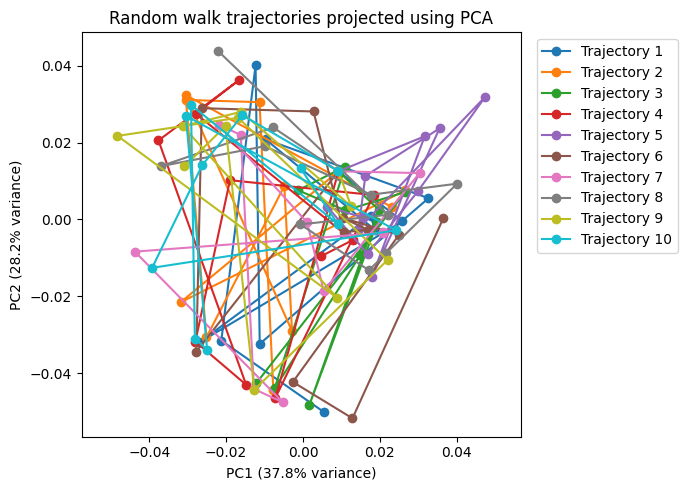

In [98]:


# x.shape == (2, 10, 64)
points = x.detach().cpu().numpy()
n_steps, n_trajectories, n_latent = points.shape

# Treat every step of every trajectory as a sample
pca = PCA(n_components=64)
projected = pca.fit_transform(points.reshape(-1, 64))
projected = projected.reshape(n_steps, n_trajectories, 64)

fig, ax = plt.subplots(figsize=(7, 5))

pca_dims = (2, 1)
for i in range(10):
    trajectory = projected[:, i, :]
    line, = ax.plot(
        trajectory[:, pca_dims[0]], trajectory[:, pca_dims[1]],
        marker="o", label=f"Trajectory {i + 1}"
    )
    # Mark the starting point with a square
    # ax.scatter(*trajectory[0][pca_dims], marker="s", color=line.get_color())

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Random walk trajectories projected using PCA")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()

In [ ]:
torch.linalg.norm(sorbes_step_result.positions - latent_background)

tensor(0.0143, grad_fn=<LinalgVectorNormBackward0>)

In [137]:
sorbes_step_result.adjusted_time_steps

tensor([1.0000e-06])

In [99]:
sorbes_step_result.geometry.active_mask

tensor([[ True,  True,  True,  True,  True,  True,  True,  True, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False],
        [ True,  True,  True,  True,  True,  True, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False

## MUTANG and Random Walks Together

In [ ]:
latent_positions = latent_background.repeat(10, 1)

steps = [latent_positions]

for i in range(10):
    sorbes_step_result = sorbes.step(latent_positions)
    steps.append(sorbes_step_result.positions)

steps = torch.stack(steps, dim=0)

# Optimization
